# Poisson Process: counts, waiting times, and independent increments

This experiment studies one homogeneous Poisson process from two equivalent viewpoints: counting arrivals in a time interval and summing exponential waiting times. Every result below is generated with explicit fixed seeds.

## 1. Problem

Let $\{N(t):t\geq0\}$ be a homogeneous Poisson process with rate $\lambda=2$ arrivals per unit time. We investigate:

1. Whether $N(t)$ follows a Poisson distribution with mean $\lambda t$.
2. Whether successive inter-arrival times follow $\operatorname{Exp}(\lambda)$.
3. Whether increments over disjoint time intervals behave independently.
4. Whether the exponential waiting time satisfies the memoryless identity.

These questions connect the discrete random variable $N(t)$ to the continuous waiting times between its jumps.

## 2. Mathematical Background

A homogeneous Poisson process satisfies $N(0)=0$, has independent increments, and has stationary increments. For $0\leq s<t$,

$$N(t)-N(s)\sim\operatorname{Poisson}(\lambda(t-s)).$$

In particular, $N(t)\sim\operatorname{Poisson}(\lambda t)$. If $T_1$ is the first arrival time, then

$$P(T_1>t)=P(N(t)=0)=e^{-\lambda t},$$

so $T_1\sim\operatorname{Exp}(\lambda)$. After any arrival, independent and stationary increments restart the same argument. Therefore all inter-arrival times $W_1,W_2,\ldots$ are independent and identically distributed exponentials.

The arrival time of event $k$ is $A_k=W_1+\cdots+W_k$. Conversely, $N(t)$ is the largest $k$ for which $A_k\leq t$.

## 3. Theoretical Result

For a rate-$\lambda$ Poisson process,

$$E[N(t)]=\lambda t,\qquad \operatorname{Var}(N(t))=\lambda t,$$

and for a waiting time $W\sim\operatorname{Exp}(\lambda)$,

$$E[W]=\frac{1}{\lambda},\qquad \operatorname{Var}(W)=\frac{1}{\lambda^2}.$$

The memoryless property states

$$P(W>s+u\mid W>s)=P(W>u)=e^{-\lambda u}.$$

Independent increments is stronger than zero correlation. We can check correlations numerically, but a finite simulation cannot prove independence; the property belongs to the model definition and theoretical construction.

## 4. Numerical Experiment

In [1]:
from math import ceil
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from scipy.stats import expon, poisson

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "src" / "poisson_process.py").exists(), "Run from the repository root or notebooks/"
sys.path.insert(0, str(project_root))

from src.poisson_process import (
    simulate_arrival_times,
    simulate_count_paths,
    simulate_interarrival_times,
)

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)
rate = 2.0
horizon = 4.0
n_paths = 10_000
time_grid = np.linspace(0, horizon, 81)
count_paths = simulate_count_paths(rate, time_grid, n_paths, np.random.default_rng(20260926))

for time in (1.0, 2.0, 4.0):
    index = int(round(time / horizon * (len(time_grid) - 1)))
    counts = count_paths[:, index]
    print(
        f"t={time:.0f}: empirical mean={np.mean(counts):.3f}, "
        f"empirical variance={np.var(counts, ddof=1):.3f}, theory={rate*time:.3f}"
    )

t=1: empirical mean=2.017, empirical variance=1.973, theory=2.000
t=2: empirical mean=4.006, empirical variance=3.945, theory=4.000
t=4: empirical mean=8.005, empirical variance=8.217, theory=8.000


In [2]:
n_waits = 100_000
waits = simulate_interarrival_times(rate, n_waits, np.random.default_rng(20260927))
s, u = 0.6, 0.8
conditional_estimate = np.mean(waits[waits > s] > s + u)
memoryless_target = np.exp(-rate * u)

increment_grid = np.array([0.0, 1.0, 2.0, 4.0])
increment_paths = simulate_count_paths(
    rate, increment_grid, 50_000, np.random.default_rng(20260928)
)
increments = np.diff(increment_paths, axis=1)
correlations = np.corrcoef(increments, rowvar=False)

print(f"Waiting-time mean: {np.mean(waits):.4f}; theory: {1/rate:.4f}")
print(f"Waiting-time variance: {np.var(waits, ddof=1):.4f}; theory: {1/rate**2:.4f}")
print(f"P(W > {s+u:.1f} | W > {s:.1f}): {conditional_estimate:.4f}; theory: {memoryless_target:.4f}")
print("Increment correlation matrix for [0,1], [1,2], [2,4]:")
print(np.round(correlations, 4))

Waiting-time mean: 0.4995; theory: 0.5000
Waiting-time variance: 0.2481; theory: 0.2500
P(W > 1.4 | W > 0.6): 0.1976; theory: 0.2019
Increment correlation matrix for [0,1], [1,2], [2,4]:
[[ 1.0e+00  1.0e-04  1.3e-03]
 [ 1.0e-04  1.0e+00 -2.7e-03]
 [ 1.3e-03 -2.7e-03  1.0e+00]]


The count experiment uses 10,000 independently simulated paths. Waiting times use a separate random stream. For independent increments, 50,000 paths provide three counts on disjoint intervals; their empirical correlation matrix should have diagonal entries one and off-diagonal entries near zero.

## 5. Visualization

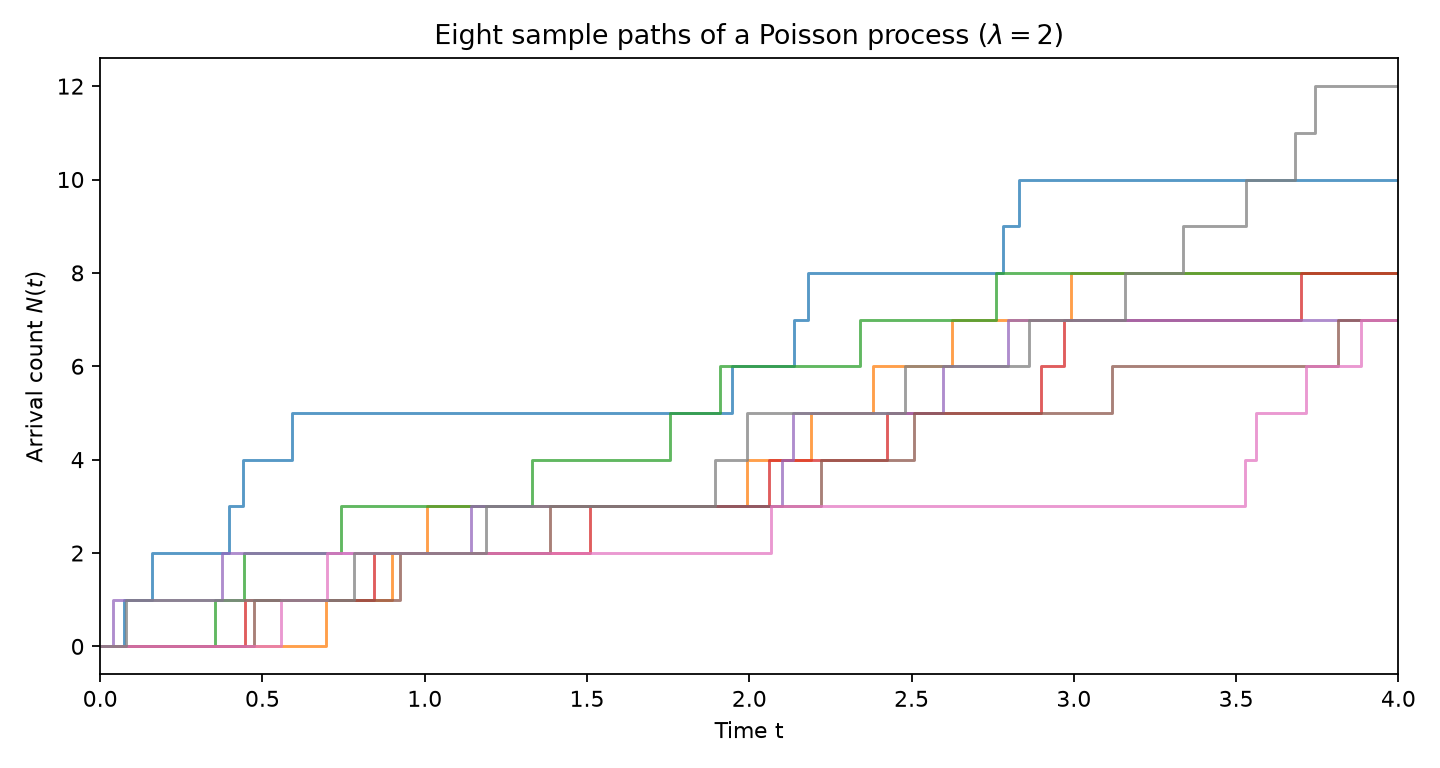

In [3]:
fig, ax = plt.subplots(figsize=(9, 4.8))
for path_id in range(8):
    arrivals = simulate_arrival_times(rate, horizon, np.random.default_rng(20261000 + path_id))
    plot_times = np.r_[0.0, arrivals, horizon]
    plot_counts = np.r_[0, np.arange(1, arrivals.size + 1), arrivals.size]
    ax.step(plot_times, plot_counts, where="post", alpha=0.75, linewidth=1.3)
ax.set(title=r"Eight sample paths of a Poisson process ($\lambda=2$)",
       xlabel="Time t", ylabel=r"Arrival count $N(t)$", xlim=(0, horizon))
fig.tight_layout()
path = figure_dir / "poisson_process_sample_paths.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

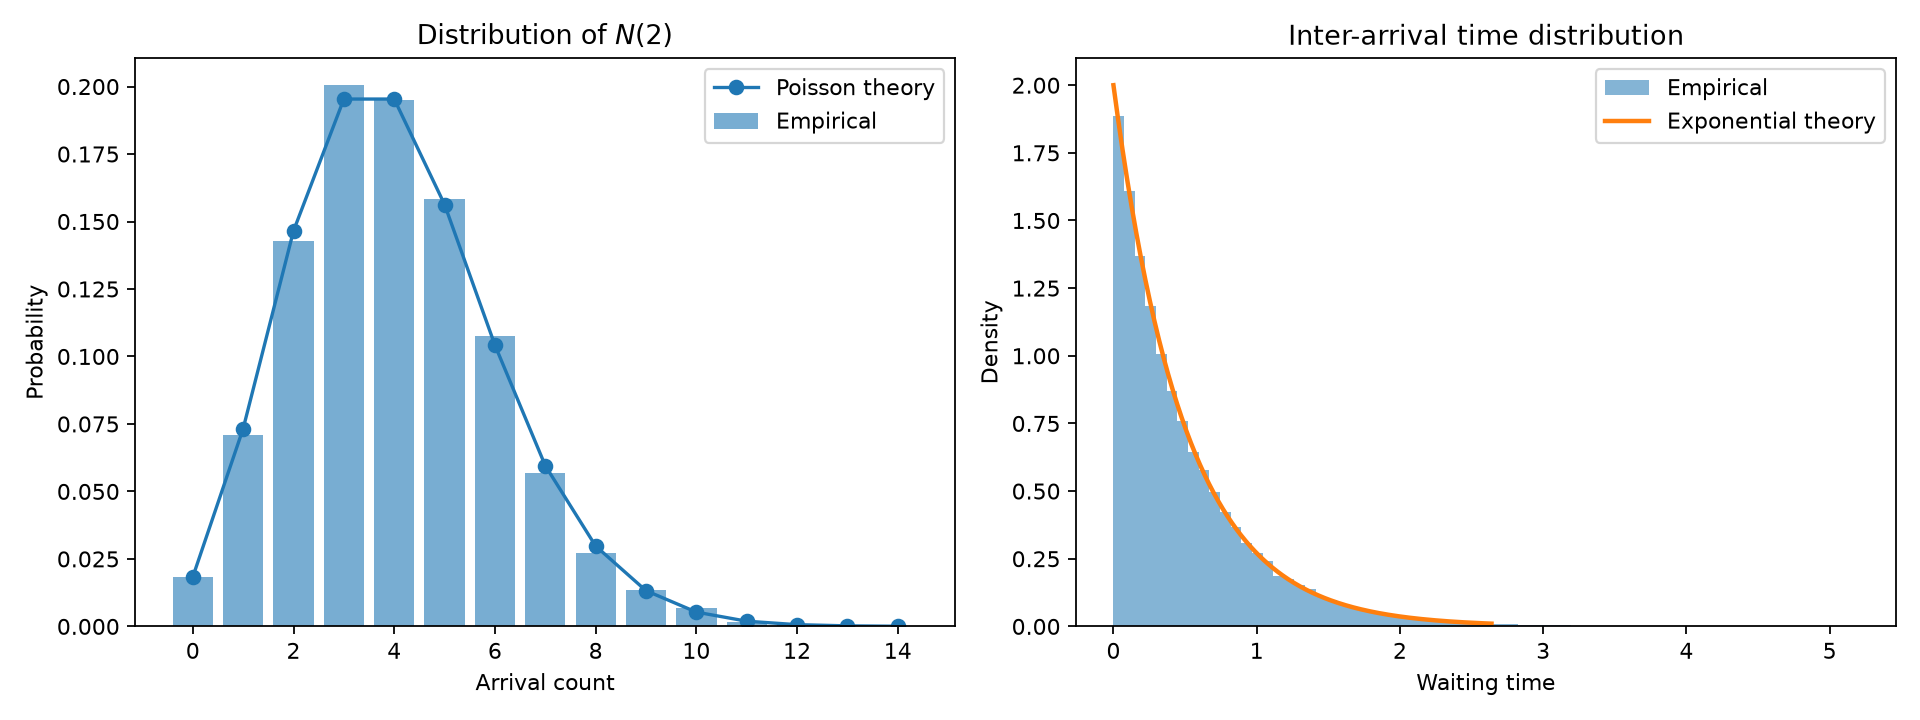

In [4]:
time = 2.0
index = int(round(time / horizon * (len(time_grid) - 1)))
counts = count_paths[:, index]
k_max = max(int(np.max(counts)), int(poisson.ppf(0.999, rate * time)))
k = np.arange(k_max + 1)
frequencies = np.bincount(counts, minlength=k_max + 1)[:k_max + 1] / counts.size

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].bar(k, frequencies, alpha=0.6, label="Empirical")
axes[0].plot(k, poisson.pmf(k, rate * time), "o-", label="Poisson theory")
axes[0].set(title=r"Distribution of $N(2)$", xlabel="Arrival count", ylabel="Probability")
axes[0].legend()

x = np.linspace(0, np.quantile(waits, 0.995), 250)
axes[1].hist(waits, bins=70, density=True, alpha=0.55, label="Empirical")
axes[1].plot(x, expon.pdf(x, scale=1/rate), linewidth=2, label="Exponential theory")
axes[1].set(title="Inter-arrival time distribution", xlabel="Waiting time", ylabel="Density")
axes[1].legend()
fig.tight_layout()
path = figure_dir / "poisson_count_and_waiting_distributions.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

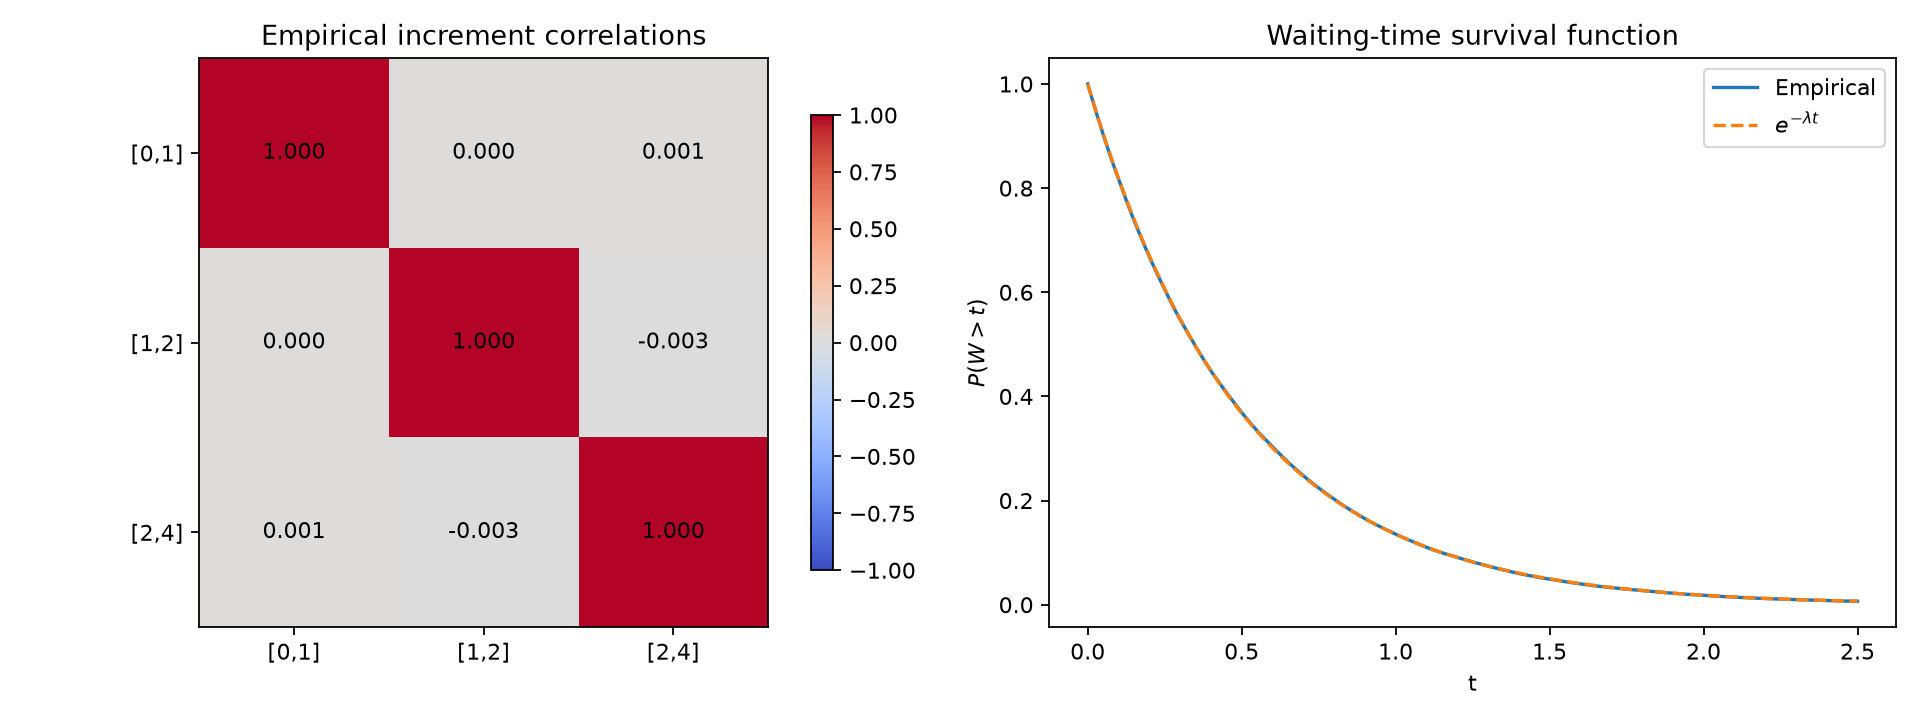

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
image = axes[0].imshow(correlations, vmin=-1, vmax=1, cmap="coolwarm")
labels = ["[0,1]", "[1,2]", "[2,4]"]
axes[0].set_xticks(range(3), labels)
axes[0].set_yticks(range(3), labels)
axes[0].set_title("Empirical increment correlations")
for i in range(3):
    for j in range(3):
        axes[0].text(j, i, f"{correlations[i, j]:.3f}", ha="center", va="center")
fig.colorbar(image, ax=axes[0], shrink=0.8)

thresholds = np.linspace(0, 2.5, 100)
empirical_survival = np.array([np.mean(waits > threshold) for threshold in thresholds])
axes[1].plot(thresholds, empirical_survival, label="Empirical")
axes[1].plot(thresholds, np.exp(-rate * thresholds), "--", label=r"$e^{-\lambda t}$")
axes[1].set(title="Waiting-time survival function", xlabel="t", ylabel=r"$P(W>t)$")
axes[1].legend()
fig.tight_layout()
path = figure_dir / "poisson_independent_increments_and_survival.png"
fig.savefig(path, dpi=160)
plt.close(fig)
display(Image(filename=str(path)))

## 6. Comparison with Theory

The tables compare empirical count means and sample variances with $\lambda t$. The $N(2)$ chart compares the entire empirical probability mass function with $\operatorname{Poisson}(4)$, so agreement is checked beyond the first two moments.

The waiting-time histogram and survival curve are compared with the exponential density and $e^{-\lambda t}$. The conditional probability calculation directly checks one instance of memorylessness. Small nonzero off-diagonal correlations are expected from finite samples; values near zero are consistent with independent increments but do not prove them.

## 7. Interpretation

Counts and waiting times describe the same random mechanism. Saying “four arrivals are expected by time two” is the count viewpoint, since $E[N(2)]=4$. Saying “the average gap is one half time unit” is the waiting-time viewpoint, since $E[W]=1/2$.

Memorylessness means that after waiting $s$ time units without an arrival, the remaining wait has the same distribution as a fresh exponential wait. It does not mean a realized waiting time has no age; it is a statement about conditional probabilities.

Independent increments concern full joint distributions on disjoint intervals. Zero empirical correlation is only a useful diagnostic because correlation alone cannot establish independence in general.

## 8. Limitations

- The experiment assumes a constant rate. Real arrival systems often have rates that vary with time or depend on past events.
- A finite sample cannot prove a distributional identity or independence; it can only reveal agreement or disagreement at the simulated scale.
- Histogram shapes depend on bin choices, so the survival curve and numerical summaries provide complementary checks.
- Fixed seeds make the notebook reproducible, but another seed will produce slightly different empirical errors.